In [26]:
import os
import random
import shutil
from collections import defaultdict
from constants import *

# FOOD101_ROOT = "D:/CitrusBits/pythonic-rebirth/datasets/food-101/food-101"
FOOD101_ROOT = os.path.join(DATASETS_DIR, "food-101/food-101")
IMAGES_DIR = os.path.join(FOOD101_ROOT, "images")
META_DIR = os.path.join(FOOD101_ROOT, "meta")

TRAIN_TXT = os.path.join(META_DIR, "train.txt")
TEST_TXT = os.path.join(META_DIR, "test.txt")

SELECTED_CLASSES = [
    'pizza', 'sushi', 'ice_cream', 'hamburger', 'ramen',
    'tacos', 'donuts', 'french_fries', 'chicken_wings', 'steak',
    'apple_pie', 'caesar_salad', 'pancakes', 'spaghetti_bolognese', 'waffles'
]
N_TRAIN_PER_CLASS = 200
N_TEST_PER_CLASS = 60

random.seed(RANDOM_SEED)


def read_split_file(path):
    class_to_files = defaultdict(list)
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_name, file_id = line.split('/')
            class_to_files[class_name].append(file_id)
    return class_to_files


train_split = read_split_file(TRAIN_TXT)
test_split = read_split_file(TEST_TXT)

SUBSET_DIR = os.path.join(FOOD101_ROOT, "subset")
os.makedirs(SUBSET_DIR, exist_ok=True)


def build_subset(split_dict, class_list, n_per_class, split_name):
    dest_root = os.path.join(SUBSET_DIR, split_name)
    for class_name in class_list:
        available = split_dict[class_name]
        sampled = random.sample(available, min(n_per_class, len(available)))
        dest_dir = os.path.join(dest_root, class_name)
        os.makedirs(dest_dir, exist_ok=True)
        for file_id in sampled:
            src = os.path.join(IMAGES_DIR, class_name, f"{file_id}.jpg")
            dst = os.path.join(dest_dir, f"{file_id}.jpg")
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
    print(f"Built '{split_name}' subset: {len(class_list)} classes x up to {n_per_class} images")


build_subset(train_split, SELECTED_CLASSES, N_TRAIN_PER_CLASS, "train")
build_subset(test_split, SELECTED_CLASSES, N_TEST_PER_CLASS, "test")

print(f"Subset created at: {SUBSET_DIR}")

Built 'train' subset: 15 classes x up to 200 images
Built 'test' subset: 15 classes x up to 60 images
Subset created at: D:/CitrusBits/pythonic-rebirth\datasets\food-101/food-101\subset


In [27]:
import tensorflow as tf

SUBSET_DIR = os.path.join(DATASETS_DIR, "food-101/food-101/subset")
IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = os.path.join(SUBSET_DIR, "train")
test_dir = os.path.join(SUBSET_DIR, "test")

# 90/10 train/val split, same as your PyTorch random_split
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
    validation_split=0.1,
    subset="training",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
    validation_split=0.1,
    subset="validation",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = full_train_ds.class_names
print("Classes:", class_names)
print(f"Train batches: {len(full_train_ds)}, Val batches: {len(val_ds)}, Test batches: {len(test_ds)}")

Found 3000 files belonging to 15 classes.
Using 2700 files for training.
Found 3000 files belonging to 15 classes.
Using 300 files for validation.
Found 900 files belonging to 15 classes.
Classes: ['apple_pie', 'caesar_salad', 'chicken_wings', 'donuts', 'french_fries', 'hamburger', 'ice_cream', 'pancakes', 'pizza', 'ramen', 'spaghetti_bolognese', 'steak', 'sushi', 'tacos', 'waffles']
Train batches: 85, Val batches: 10, Test batches: 29


In [28]:
# Augmentation layers — mirrors your RandomHorizontalFlip + RandomRotation(10)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(10 / 360),
    # Keras rotation factor is a fraction of 2*pi turns... actually of full 360, so 10 degrees ≈ 10/360
])

# ResNet-style preprocessing expects the same ImageNet mean/std normalization
# tf.keras.applications.resnet.preprocess_input handles this for us (matches transforms.Normalize)
preprocess_input = tf.keras.applications.resnet.preprocess_input


def prepare(ds, training=False):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


train_ds_prepped = prepare(full_train_ds, training=True)
val_ds_prepped = prepare(val_ds, training=False)
test_ds_prepped = prepare(test_ds, training=False)

print("Pipelines ready")

Pipelines ready


In [29]:
NUM_CLASSES = 15

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all pretrained layers — matches your PyTorch loop where only resnet.fc trained
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # equivalent role to ResNet18's pooled feature vector
outputs = tf.keras.layers.Dense(NUM_CLASSES)(x)  # logits, no softmax — matches CrossEntropyLoss expecting raw logits

resnet_tf = tf.keras.Model(inputs, outputs)

resnet_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # matches your PyTorch lr
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

resnet_tf.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [30]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

os.makedirs(MODELS_DIR, exist_ok=True)
RESNET_TF_PATH = os.path.join(MODELS_DIR, "food101_resnet50_transfer_tf.keras")

if os.path.exists(RESNET_TF_PATH):
    print(f"Found existing model at {RESNET_TF_PATH}, loading instead of retraining...")
    resnet_tf = tf.keras.models.load_model(RESNET_TF_PATH)
else:
    print("No saved model found, training transfer learning model...")
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    lr_damping = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    history = resnet_tf.fit(
        train_ds_prepped,
        validation_data=val_ds_prepped,
        epochs=20,
        callbacks=[early_stop, lr_damping]
    )
    resnet_tf.save(RESNET_TF_PATH)
    print(f"Model saved to {RESNET_TF_PATH}")

Found existing model at D:/CitrusBits/pythonic-rebirth\models\food101_resnet50_transfer_tf.keras, loading instead of retraining...


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds = []
all_labels = []

for images, labels in test_ds_prepped:
    logits = resnet_tf.predict(images, verbose=0)
    preds = np.argmax(logits, axis=1)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}")

print(classification_report(all_labels, all_preds, target_names=class_names))
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 0.8078
                     precision    recall  f1-score   support

          apple_pie       0.62      0.53      0.57        60
       caesar_salad       0.79      0.83      0.81        60
      chicken_wings       0.86      0.85      0.86        60
             donuts       0.77      0.88      0.82        60
       french_fries       0.89      0.92      0.90        60
          hamburger       0.91      0.68      0.78        60
          ice_cream       0.86      0.83      0.85        60
           pancakes       0.72      0.78      0.75        60
              pizza       0.92      0.93      0.93        60
              ramen       0.81      1.00      0.90        60
spaghetti_bolognese       0.95      0.90      0.92        60
              steak       0.72      0.83      0.78        60
              sushi       0.80      0.73      0.77        60
              tacos       0.76      0.68      0.72        60
            waffles       0.75      0.72      0.74        60



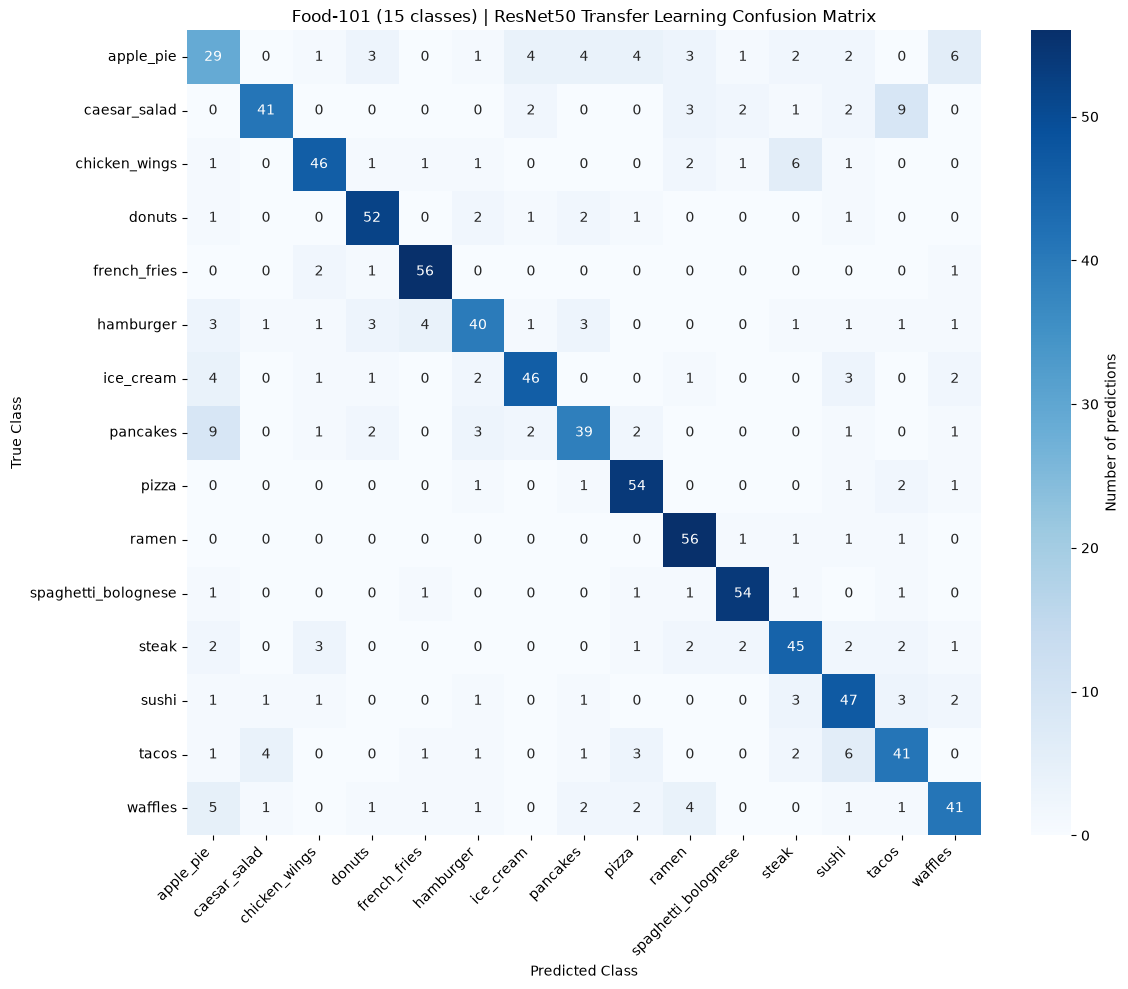

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([
    [29, 0, 1, 3, 0, 1, 4, 4, 4, 3, 1, 2, 2, 0, 6],
    [0, 41, 0, 0, 0, 0, 2, 0, 0, 3, 2, 1, 2, 9, 0],
    [1, 0, 46, 1, 1, 1, 0, 0, 0, 2, 1, 6, 1, 0, 0],
    [1, 0, 0, 52, 0, 2, 1, 2, 1, 0, 0, 0, 1, 0, 0],
    [0, 0, 2, 1, 56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [3, 1, 1, 3, 4, 40, 1, 3, 0, 0, 0, 1, 1, 1, 1],
    [4, 0, 1, 1, 0, 2, 46, 0, 0, 1, 0, 0, 3, 0, 2],
    [9, 0, 1, 2, 0, 3, 2, 39, 2, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 1, 54, 0, 0, 0, 1, 2, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 56, 1, 1, 1, 1, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 54, 1, 0, 1, 0],
    [2, 0, 3, 0, 0, 0, 0, 0, 1, 2, 2, 45, 2, 2, 1],
    [1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 3, 47, 3, 2],
    [1, 4, 0, 0, 1, 1, 0, 1, 3, 0, 0, 2, 6, 41, 0],
    [5, 1, 0, 1, 1, 1, 0, 2, 2, 4, 0, 0, 1, 1, 41],
])

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of predictions'}
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Food-101 (15 classes) | ResNet50 Transfer Learning Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
from PIL import Image


def extract_features(image_path, thumb_size=(32, 32)):
    img = Image.open(image_path).convert("RGB").resize(thumb_size)
    arr = np.array(img).astype(np.float32) / 255.0

    # Flattened thumbnail pixels
    flat_pixels = arr.flatten()

    # Per-channel mean and std (simple color summary stats)
    channel_means = arr.mean(axis=(0, 1))
    channel_stds = arr.std(axis=(0, 1))

    return np.concatenate([flat_pixels, channel_means, channel_stds])


def build_feature_dataset(root_dir, class_list):
    X, y = [], []
    for label_idx, class_name in enumerate(class_list):
        class_dir = os.path.join(root_dir, class_name)
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            X.append(extract_features(fpath))
            y.append(label_idx)
    return np.array(X), np.array(y)


train_dir = os.path.join(SUBSET_DIR, "train")
test_dir = os.path.join(SUBSET_DIR, "test")

X_train_feat, y_train_feat = build_feature_dataset(train_dir, class_names)
X_test_feat, y_test_feat = build_feature_dataset(test_dir, class_names)

print("Train features shape:", X_train_feat.shape)
print("Test features shape:", X_test_feat.shape)

Train features shape: (3000, 3078)
Test features shape: (900, 3078)


In [34]:
from xgboost import XGBClassifier
import joblib
import os

xgb_food_path = os.path.join(MODELS_DIR, "food101_xgb.pkl")

if os.path.exists(xgb_food_path):
    xgb_food_model = joblib.load(xgb_food_path)
    print("Loaded existing XGBoost model.")
else:
    xgb_food_model = XGBClassifier(random_state=RANDOM_SEED, max_depth=6, n_estimators=200)
    xgb_food_model.fit(X_train_feat, y_train_feat)
    joblib.dump(xgb_food_model, xgb_food_path)
    print("XGBoost model saved to", xgb_food_path)

xgb_food_preds = xgb_food_model.predict(X_test_feat)
xgb_food_test_acc = np.mean(xgb_food_preds == y_test_feat)
print(f"XGBoost Test Accuracy: {xgb_food_test_acc:.4f}")

Loaded existing XGBoost model.
XGBoost Test Accuracy: 0.2356


In [35]:
print(f"{'Model':<30}{'Test Accuracy':<15}")
print(f"{'ResNet50 Transfer Learning':<30}{test_acc:<15.4f}")
print(f"{'XGBOOST Accuracy':<30}{xgb_food_test_acc:<15.4f}")

Model                         Test Accuracy  
ResNet50 Transfer Learning    0.8078         
XGBOOST Accuracy              0.2356         
